In [2]:
%pip install matplotlib seaborn scikit-learn requests


[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
# from google.colab import files

In [ ]:
# ============================================================
# 2. DOWNLOAD DATI ISTAT
# ============================================================

url = "https://esploradati.istat.it/SDMXWS/rest/data/41_983"
headers = {'Accept': 'application/vnd.sdmx.data+csv;version=1.0.0'}

response = requests.get(url, headers=headers)
df = pd.read_csv(io.StringIO(response.text))

print(response)
print(df.head())
print(df.shape)

In [ ]:
# siccome ci mette tanto a scaricare i dati, li ho salvati in locale e ora li carico da lì
# import pandas as pd

# df = pd.read_csv("C:\\Users\\gabri\\Desktop\\boolean\\dati_istat_esportati.csv")

In [3]:
df.head()

,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,NOTE_DATA_TYPE,NOTE_RESULT,NOTE_TIME_PERIOD,BASE_PER,UNIT_MEAS,UNIT_MULT
0,IT1:41_983(1.0),A,1001,KILLINJ,F,2001,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IT1:41_983(1.0),A,1001,KILLINJ,F,2002,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IT1:41_983(1.0),A,1001,KILLINJ,F,2003,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IT1:41_983(1.0),A,1001,KILLINJ,F,2004,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IT1:41_983(1.0),A,1001,KILLINJ,F,2005,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# ============================================================
# 3. PULIZIA INIZIALE
# ============================================================

df_clean = df.copy()

# Tolgo colonne completamente vuote
df_clean = df_clean.dropna(axis=1, how='all')

# Tengo solo righe con OBS_VALUE valorizzato
df_clean = df_clean.dropna(subset=['OBS_VALUE'])

# Controllo tipi
df_clean['TIME_PERIOD'] = pd.to_numeric(df_clean['TIME_PERIOD'], errors='coerce')
df_clean['OBS_VALUE'] = pd.to_numeric(df_clean['OBS_VALUE'], errors='coerce')

df_clean = df_clean.dropna(subset=['TIME_PERIOD', 'OBS_VALUE'])

print(df_clean.info())
print(df_clean['OBS_VALUE'].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573552 entries, 0 to 573551
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   DATAFLOW     573552 non-null  object
 1   FREQ         573552 non-null  object
 2   REF_AREA     573552 non-null  int64 
 3   DATA_TYPE    573552 non-null  object
 4   RESULT       573552 non-null  object
 5   TIME_PERIOD  573552 non-null  int64 
 6   OBS_VALUE    573552 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 30.6+ MB
None
count    573552.000000
mean         20.207603
std         245.813966
min           0.000000
25%           0.000000
50%           1.000000
75%           8.000000
max       30254.000000
Name: OBS_VALUE, dtype: float64


In [5]:
# ============================================================
# 4. CARICAMENTO FILE COMUNI E JOIN
# ============================================================

df_comuni = pd.read_csv("C:\\Users\\gabri\\Desktop\\boolean\\Comuni - Dimensione Data Indagine 31-12-2020 Stampa 08052026194159.csv",
    sep=';'
)

df_join = pd.merge(
    df_clean,
    df_comuni,
    left_on='REF_AREA',
    right_on='Codice Comune (numerico)',
    how='left'
)

print(df_join.head())
print(df_join[['REF_AREA', 'Codice Comune (numerico)', 'Popolazione legale']].head())

          DATAFLOW FREQ  REF_AREA DATA_TYPE RESULT  TIME_PERIOD  OBS_VALUE  \
0  IT1:41_983(1.0)    A      1001   KILLINJ      F         2001         10   
1  IT1:41_983(1.0)    A      1001   KILLINJ      F         2002         10   
2  IT1:41_983(1.0)    A      1001   KILLINJ      F         2003          7   
3  IT1:41_983(1.0)    A      1001   KILLINJ      F         2004         13   
4  IT1:41_983(1.0)    A      1001   KILLINJ      F         2005          2   

   Codice Ripartizione geografica  Codice Regione  Codice Provincia (Storico)  \
0                             1.0             1.0                         1.0   
1                             1.0             1.0                         1.0   
2                             1.0             1.0                         1.0   
3                             1.0             1.0                         1.0   
4                             1.0             1.0                         1.0   

   ...  Codice Comune (numerico)  Comune  Co

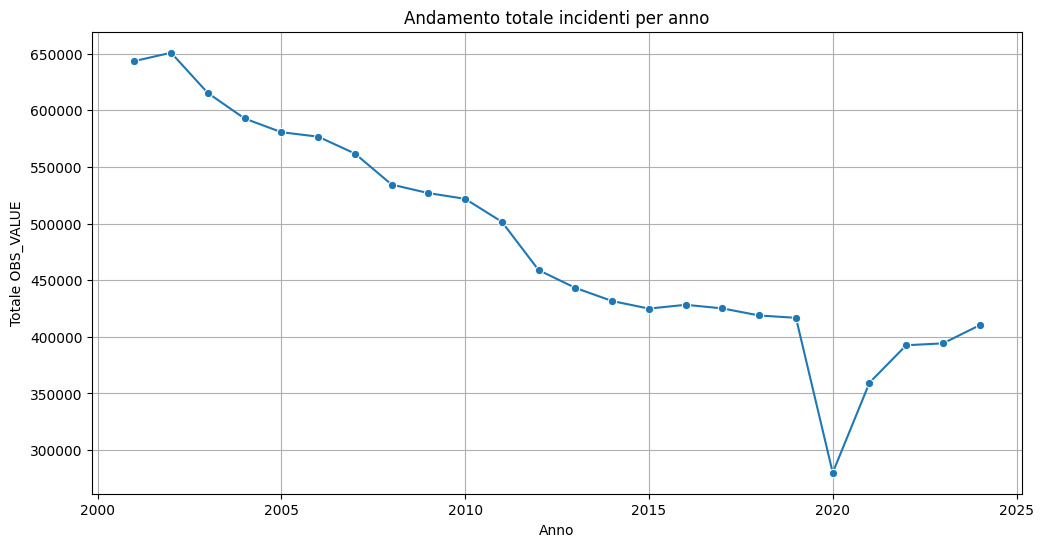

In [6]:
# ============================================================
# 5. ANALISI TREND ANNUALE SU VALORI ASSOLUTI
# ============================================================

trend_annuale = df_clean.groupby('TIME_PERIOD', as_index=False)['OBS_VALUE'].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_annuale, x='TIME_PERIOD', y='OBS_VALUE', marker='o')
plt.title('Andamento totale incidenti per anno')
plt.xlabel('Anno')
plt.ylabel('Totale OBS_VALUE')
plt.grid(True)
plt.show()

Righe originali: 573552
Righe dopo outlier: 521486
Righe rimosse: 52066


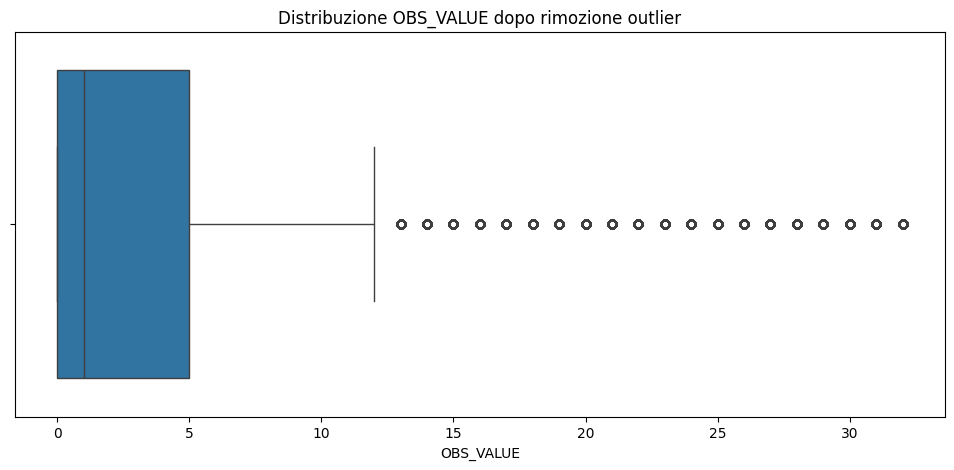

In [7]:
# ============================================================
# 6. RIMOZIONE OUTLIER
# ============================================================

Q1 = df_clean['OBS_VALUE'].quantile(0.25)
Q3 = df_clean['OBS_VALUE'].quantile(0.75)
IQR = Q3 - Q1

limite_inferiore = Q1 - 3.0 * IQR
limite_superiore = Q3 + 3.0 * IQR

df_senza_outlier = df_clean[
    (df_clean['OBS_VALUE'] >= limite_inferiore) &
    (df_clean['OBS_VALUE'] <= limite_superiore)
].copy()

print("Righe originali:", len(df_clean))
print("Righe dopo outlier:", len(df_senza_outlier))
print("Righe rimosse:", len(df_clean) - len(df_senza_outlier))

plt.figure(figsize=(12, 5))
sns.boxplot(x=df_senza_outlier['OBS_VALUE'])
plt.title('Distribuzione OBS_VALUE dopo rimozione outlier')
plt.show()

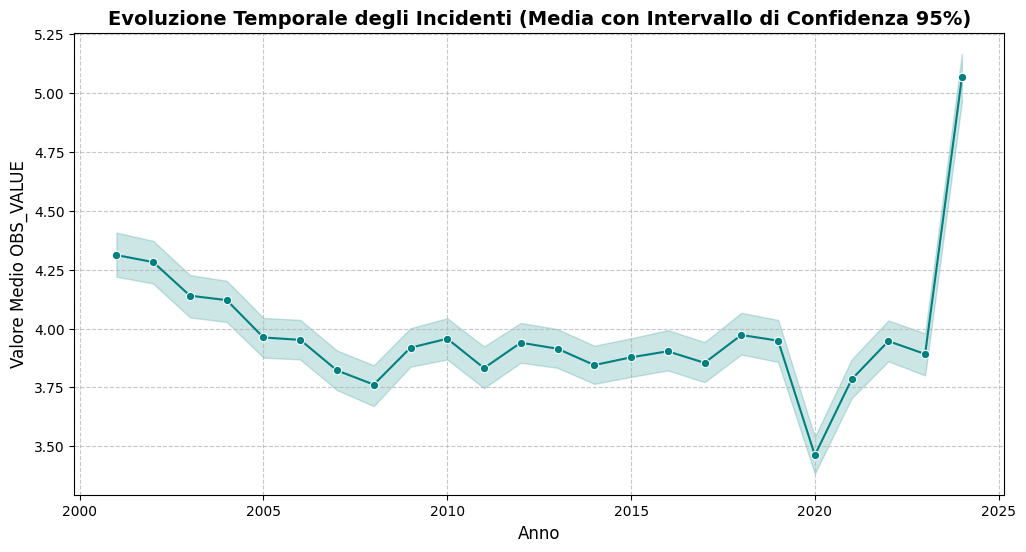


--- Ultimi anni del trend temporale ---
    TIME_PERIOD    sum      mean
19         2020  77192  3.461835
20         2021  83077  3.783795
21         2022  86207  3.946484
22         2023  84733  3.891655
23         2024  86375  5.066874


In [ ]:
# ============================================================
# 6.1 EVOLUZIONE TEMPORALE DEGLI INCIDENTI
# ============================================================

trend_temporale = df_senza_outlier.groupby('TIME_PERIOD')['OBS_VALUE'].agg(['mean', 'sum', 'count']).reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(data=df_senza_outlier, x='TIME_PERIOD', y='OBS_VALUE', color='teal', marker='o', errorbar=('ci', 95))

plt.title('Evoluzione Temporale degli Incidenti (Media con Intervallo di Confidenza 95%)', fontsize=14, fontweight='bold')
plt.xlabel('Anno', fontsize=12)
plt.ylabel('Valore Medio OBS_VALUE', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)


plt.show()

print("\n--- Ultimi anni del trend temporale ---")
print(trend_temporale[['TIME_PERIOD', 'sum', 'mean']].tail())

In [9]:
# ============================================================
# 7. ESCLUSIONE 2024
# ============================================================

df_finale = df_senza_outlier[df_senza_outlier['TIME_PERIOD'] < 2024].copy()

print("Anni usati:")
print(sorted(df_finale['TIME_PERIOD'].unique()))

Anni usati:
[np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


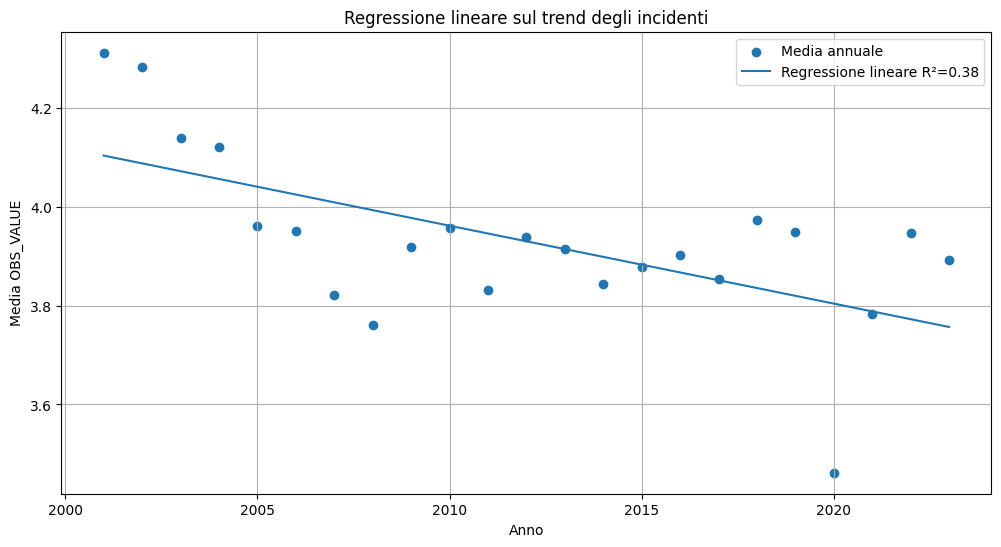

R²: 0.37948674956196604


In [10]:
# ============================================================
# 8. REGRESSIONE LINEARE
# ============================================================

trend_data = df_finale.groupby('TIME_PERIOD', as_index=False)['OBS_VALUE'].mean()

X = trend_data[['TIME_PERIOD']]
y = trend_data['OBS_VALUE']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = model.score(X, y)
pendenza = model.coef_[0]

plt.figure(figsize=(12, 6))
plt.scatter(X, y, label='Media annuale')
plt.plot(X, y_pred, label=f'Regressione lineare R²={r2:.2f}')
plt.title('Regressione lineare sul trend degli incidenti')
plt.xlabel('Anno')
plt.ylabel('Media OBS_VALUE')
plt.legend()
plt.grid(True)
plt.show()

print("R²:", r2)

In [11]:
# ============================================================
# 9. TEST STATISTICO SULLA PENDENZA
# ============================================================

X_test = sm.add_constant(X)
model_stat = sm.OLS(y, X_test).fit()

print(model_stat.summary())

p_value = model_stat.pvalues.iloc[1]

if p_value < 0.05:
    print(f"p-value = {p_value:.4f}. Trend statisticamente significativo.")
else:
    print(f"p-value = {p_value:.4f}. Trend non statisticamente significativo.")

                            OLS Regression Results                            
Dep. Variable:              OBS_VALUE   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     12.84
Date:                Sun, 24 May 2026   Prob (F-statistic):            0.00175
Time:                        11:51:13   Log-Likelihood:                 13.629
No. Observations:                  23   AIC:                            -23.26
Df Residuals:                      21   BIC:                            -20.99
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          35.6649      8.855      4.028      

In [12]:
# ============================================================
# 10. PREPARAZIONE DATI PER CLUSTERING CORRETTO
# ============================================================

# Rifaccio la join, ma usando df_finale, non df_clean
df_cluster = pd.merge(
    df_finale,
    df_comuni,
    left_on='REF_AREA',
    right_on='Codice Comune (numerico)',
    how='left'
)

# Tolgo righe senza popolazione
df_cluster = df_cluster.dropna(subset=['Popolazione legale'])

# Creo indicatore normalizzato
df_cluster['incidenti_per_1000_ab'] = (
    df_cluster['OBS_VALUE'] / df_cluster['Popolazione legale']
) * 1000

print(df_cluster[['REF_AREA', 'OBS_VALUE', 'Popolazione legale', 'incidenti_per_1000_ab']].head())

   REF_AREA  OBS_VALUE  Popolazione legale  incidenti_per_1000_ab
0      1001         10              2644.0               3.782148
1      1001         10              2644.0               3.782148
2      1001          7              2644.0               2.647504
3      1001         13              2644.0               4.916793
4      1001          2              2644.0               0.756430


In [13]:
# ============================================================
# 11. CREAZIONE DATASET FINALE PER CLUSTERING
# ============================================================

cluster_base = df_cluster.groupby('REF_AREA').agg(
    media_incidenti=('incidenti_per_1000_ab', 'mean'),
    variabilita_incidenti=('incidenti_per_1000_ab', 'std'),
    popolazione=('Popolazione legale', 'first')
).reset_index()

# Se un comune ha una sola osservazione, std è NaN: la metto a 0
cluster_base['variabilita_incidenti'] = cluster_base['variabilita_incidenti'].fillna(0)

In [14]:
# ============================================================
# 12. STANDARDIZZAZIONE VARIABILI
# ============================================================

features = cluster_base[['media_incidenti', 'variabilita_incidenti']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

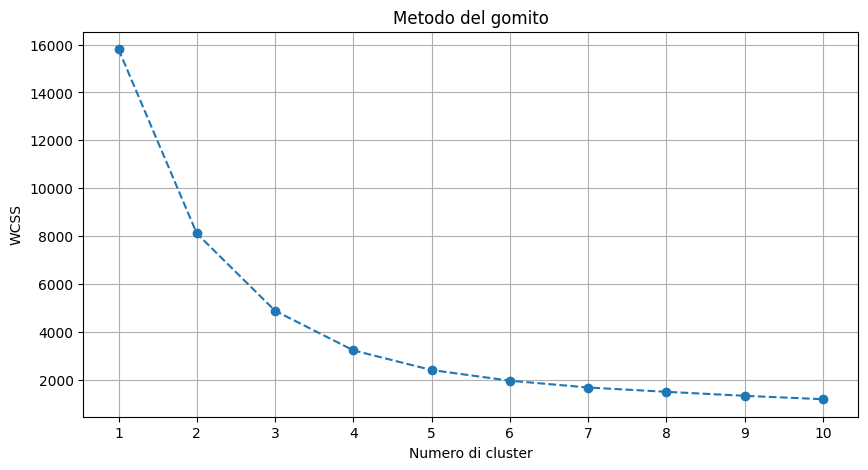

In [15]:
# ============================================================
# 13. METODO DEL GOMITO
# ============================================================

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Metodo del gomito')
plt.xlabel('Numero di cluster')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [16]:
# ============================================================
# 14. K-MEANS FINALE
# ============================================================

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)

cluster_base['cluster'] = kmeans_final.fit_predict(X_scaled)

print(cluster_base.head())

   REF_AREA  media_incidenti  variabilita_incidenti  popolazione  cluster
0      1001         1.370344               1.440347       2644.0        3
1      1002         2.098818               1.828547       3819.0        3
2      1003         0.407805               1.246476        462.0        0
3      1004         2.176745               2.038372       1791.0        3
4      1006         0.696701               0.654273       6303.0        0


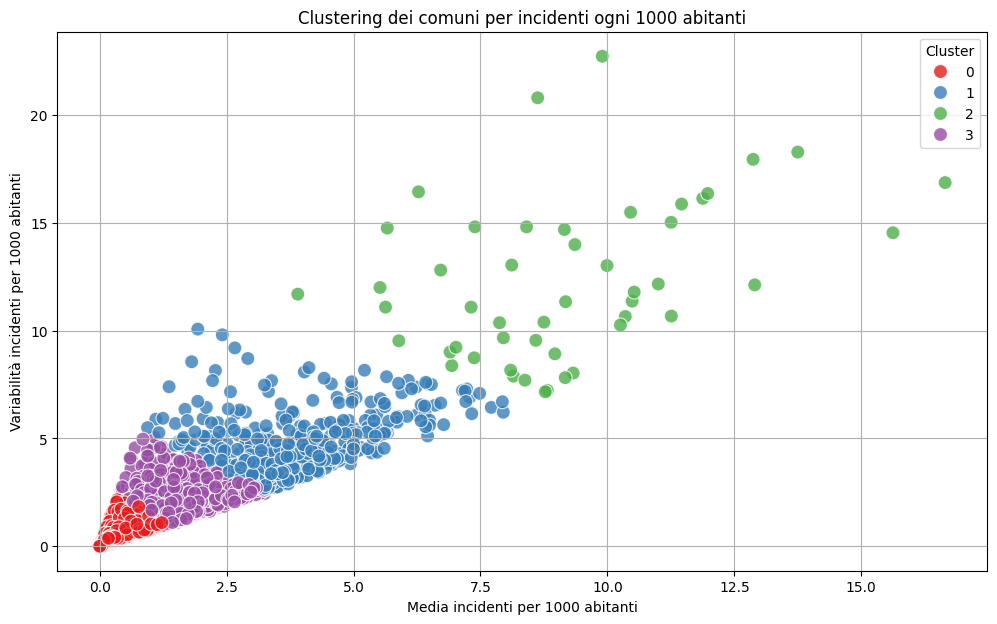

In [17]:
# ============================================================
# 15. GRAFICO CLUSTER FINALE
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=cluster_base,
    x='media_incidenti',
    y='variabilita_incidenti',
    hue='cluster',
    palette='Set1',
    s=100,
    alpha=0.8
)

plt.title('Clustering dei comuni per incidenti ogni 1000 abitanti')
plt.xlabel('Media incidenti per 1000 abitanti')
plt.ylabel('Variabilità incidenti per 1000 abitanti')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

In [18]:
# ============================================================
# 16. INTERPRETAZIONE CLUSTER
# ============================================================

riepilogo_cluster = cluster_base.groupby('cluster').agg(
    media_incidenti=('media_incidenti', 'mean'),
    variabilita_incidenti=('variabilita_incidenti', 'mean'),
    numero_comuni=('REF_AREA', 'count'),
    popolazione_media=('popolazione', 'mean')
).reset_index()

print(riepilogo_cluster.sort_values('media_incidenti'))

   cluster  media_incidenti  variabilita_incidenti  numero_comuni  \
0        0         0.554852               0.782098           4361   
3        3         1.678286               1.912240           2973   
1        1         3.737554               4.486754            519   
2        2         9.200373              12.299729             49   

   popolazione_media  
0       10681.889934  
3        3227.783047  
1        1190.329480  
2         385.040816  


In [19]:
# ============================================================
# 17. TOP COMUNI PER RISCHIO NORMALIZZATO
# ============================================================

top_comuni_cluster = cluster_base.sort_values(
    by='media_incidenti',
    ascending=False
).head(20)

print(top_comuni_cluster)

      REF_AREA  media_incidenti  variabilita_incidenti  popolazione  cluster
858       6014        16.651665              16.874109        505.0        2
653       4175        15.623605              14.546173        487.0        2
2712     21065        13.749535              18.290069        195.0        2
7394     97032        12.901561              12.126579        337.0        2
1041      7009        12.869565              17.952481        125.0        2
5515     66083        11.976048              16.366693        167.0        2
4652     58014        11.877757              16.141900        460.0        2
318       2009        11.460797              15.878391        239.0        2
389       2163        11.258697              10.679369        465.0        2
317       2008        11.255011              15.031994         94.0        2
346       2065        11.002352              12.167928        382.0        2
1498     13030        10.527075              11.792947        402.0        2